# Question 3: 

korreliert die anzahl illegal entsorgter abfälle mit den anzahl gastronomiebetrieben, dh. wo die leute ausgehen

import packages


In [20]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import datetime as dt
import numpy as np
from scipy import stats

### Access and load data via API (züri wie neu, neighbourhoods, population)

In [21]:
#Access and load the züri wie neu data via API

url_zwn = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Zueri_wie_neu?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=zwn_meldungen_p"
response_zwn = requests.get(url_zwn)
if response_zwn.status_code == 200:
    print("Data züri wie neu loaded sugessfull")
    zwn_gdf = gpd.read_file(response_zwn.url).set_crs(epsg="4326").to_crs(epsg="2056")
else:
    print("Data züri wie neu loading failed")

Data züri wie neu loaded sugessfull


In [22]:
url_neighbourhoods = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_v"
response_neighbourhoods = requests.get(url_neighbourhoods)
if response_neighbourhoods.status_code == 200:
    print("Data neighbourhood loaded sugessfull")
    neighbourhoods_gdf = gpd.read_file(response_neighbourhoods.url).set_crs(epsg="4326").to_crs(epsg="2056")
else:
    print("Data neighbourhood loading failed")

Data neighbourhood loaded sugessfull


In [23]:

#access and load the gastronomy locations

url_gastronomy = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Gastwirtschaftsbetriebe?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=gastwirtschaftsbetriebe"
response_gastronomy = requests.get(url_gastronomy)
if response_gastronomy.status_code == 200:
    print("gastronomy data loaded sugessfull")
    gastronomy_gdf = gpd.read_file(response_gastronomy.url).set_crs(epsg="4326").to_crs(epsg="2056")
else:
    print("gastronomy data loading failed")



gastronomy data loaded sugessfull


## clean and filter the data

In [39]:

gastronomy_gdf = gastronomy_gdf[["betriebsname", "quarlang"]]
neighbourhood_with_gastronomy = gastronomy_gdf["quarlang"].value_counts()
neighbourhood_with_gastronomy = neighbourhood_with_gastronomy.rename("gastronomy")

neighbourhood_with_gastronomy.info()

<class 'pandas.Series'>
Index: 34 entries, Langstrasse to Leimbach
Series name: gastronomy
Non-Null Count  Dtype
--------------  -----
34 non-null     int64
dtypes: int64(1)
memory usage: 853.0 bytes


filter the züri wie neu data for waste and important columns

In [26]:
# Sort the züri wie neu data for waste and filter the columns

zwn_waste_gdf = zwn_gdf[zwn_gdf["service_name"]=="Abfall/Sammelstelle"]
zwn_waste_gdf_filtered = zwn_waste_gdf[["service_request_id", "title", "geometry"]].copy()



filter columns in neighbourhoods file

In [27]:
#clean neighbourhoods file

neighbourhoods_gdf_filtered = neighbourhoods_gdf[["qname", "qnr", "geometry"]]


## join and merge data together

In [37]:

#join the trash points to the neighbourhoods

neighbourhoods_with_waste_df = gpd.sjoin(zwn_waste_gdf_filtered, 
                                          neighbourhoods_gdf_filtered,
                                          how="inner",
                                          predicate="within")

mask_groupby_neighbourhood = neighbourhoods_with_waste_df.groupby("qname", as_index=False)

neighbourhood_with_waste_df = neighbourhoods_with_waste_df[["qname"]].value_counts()
neighbourhood_with_waste_df = neighbourhood_with_waste_df.rename("waste")


In [40]:
# merge the gastronomy to the neighbourhoods and waste

neighbourhood_with_gastronomy_waste_df = pd.merge(left=neighbourhood_with_waste_df, 
                                        right=neighbourhood_with_gastronomy,
                                        left_on="qname",
                                        right_index=True
                                        )

neighbourhood_with_gastronomy_waste_df.head(3)
#neighbourhood_with_gastronomy_waste_df = neighbourhood_with_gastronomy_waste_df.sort_values(by="count", ascending=True)
#neighbourhood_with_gastronomy_waste_df = neighbourhood_with_gastronomy_waste_df.set_index("qname")


,waste,gastronomy
qname,,
Langstrasse,3873,361
Sihlfeld,3161,185
Hard,1636,75


In [44]:
# merge the population and waste to the geometry and calculate the pop density

neighbourhood_with_gastronomy_waste_gdf = pd.merge(left=neighbourhoods_gdf_filtered, 
                                        right=neighbourhood_with_gastronomy_waste_df,
                                        left_on="qname",
                                        right_on="qname")

neighbourhood_with_gastronomy_waste_gdf["gastronomy_density"] = neighbourhood_with_gastronomy_waste_gdf["gastronomy"]/neighbourhood_with_gastronomy_waste_gdf.geometry.area
neighbourhood_with_gastronomy_waste_gdf["waste_density"] = neighbourhood_with_gastronomy_waste_gdf["waste"]/neighbourhood_with_gastronomy_waste_gdf.geometry.area

neighbourhood_with_gastronomy_waste_gdf = neighbourhood_with_gastronomy_waste_gdf.sort_values(by= "gastronomy_density", ascending=True)


## plot data

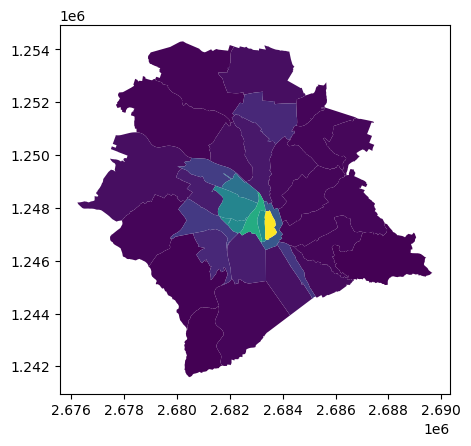

In [45]:
fig, ax = plt.subplots()
neighbourhood_with_gastronomy_waste_gdf.plot(ax=ax, column= "gastronomy_density")

plt.show()

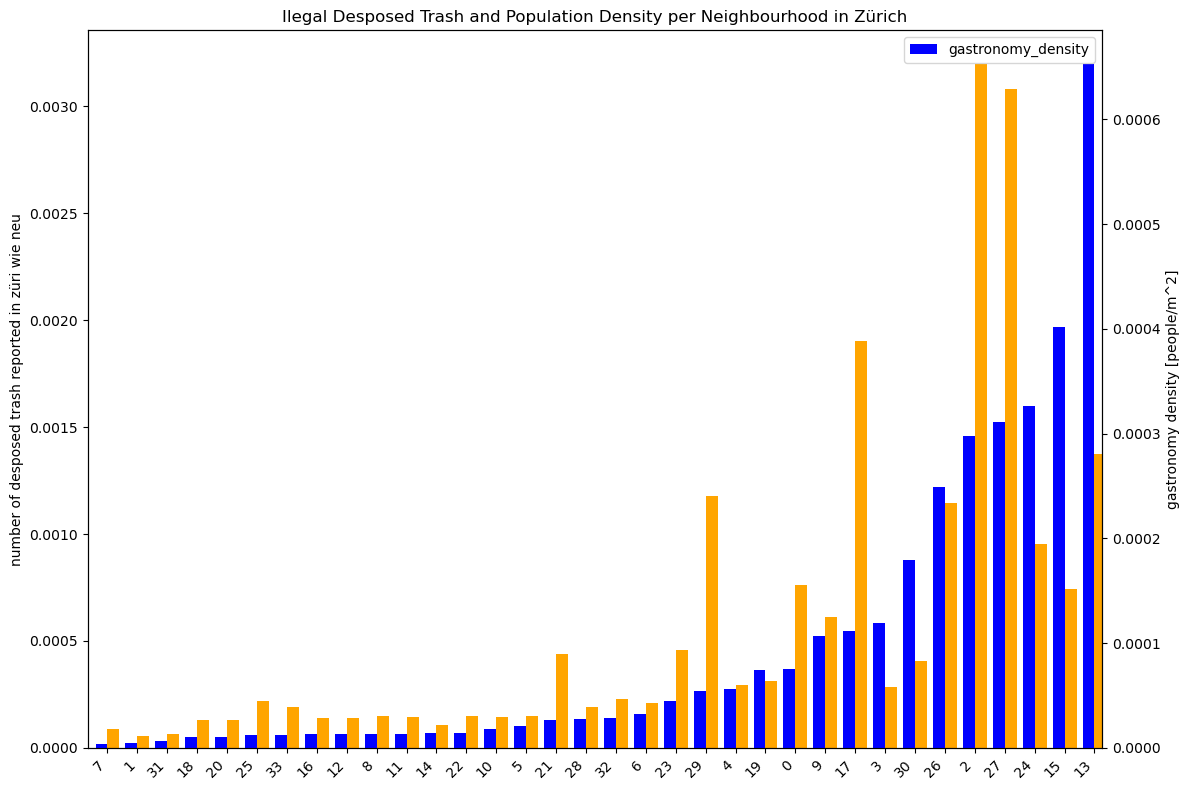

In [46]:
fig, ax1 = plt.subplots(figsize= (12,8))
ax2 = ax1.twinx()

neighbourhood_with_gastronomy_waste_gdf["waste_density"].plot(kind="bar", ax=ax1, width= 0.4, position=0, color= "orange",
                               title="Ilegal Desposed Trash and Population Density per Neighbourhood in Zürich",
                               ylabel="number of desposed trash reported in züri wie neu",
                               xlabel="")
neighbourhood_with_gastronomy_waste_gdf["gastronomy_density"].plot(kind="bar", ax=ax2, width= 0.4, position=1, color= "blue",
                         ylabel="gastronomy density [people/m^2]"
                         )
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right")
plt.tight_layout()
plt.legend()


plt.show()

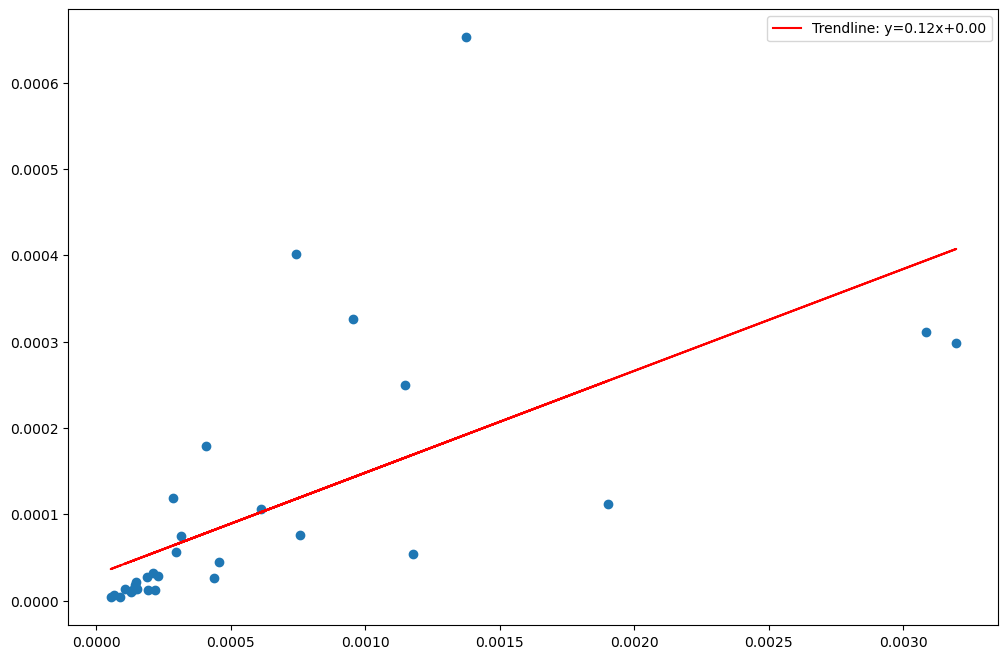

In [48]:
fig, ax3 = plt.subplots(figsize= (12,8))

ax3.scatter(neighbourhood_with_gastronomy_waste_gdf["waste_density"], neighbourhood_with_gastronomy_waste_gdf["gastronomy_density"])
m, b = np.polyfit(neighbourhood_with_gastronomy_waste_gdf["waste_density"], neighbourhood_with_gastronomy_waste_gdf["gastronomy_density"], 1)
x= neighbourhood_with_gastronomy_waste_gdf["waste_density"]
y= neighbourhood_with_gastronomy_waste_gdf["gastronomy_density"]
plt.plot(x, m*x + b, color='red', linestyle='-', label=f'Trendline: y={m:.2f}x+{b:.2f}')
plt.legend()
plt.show()


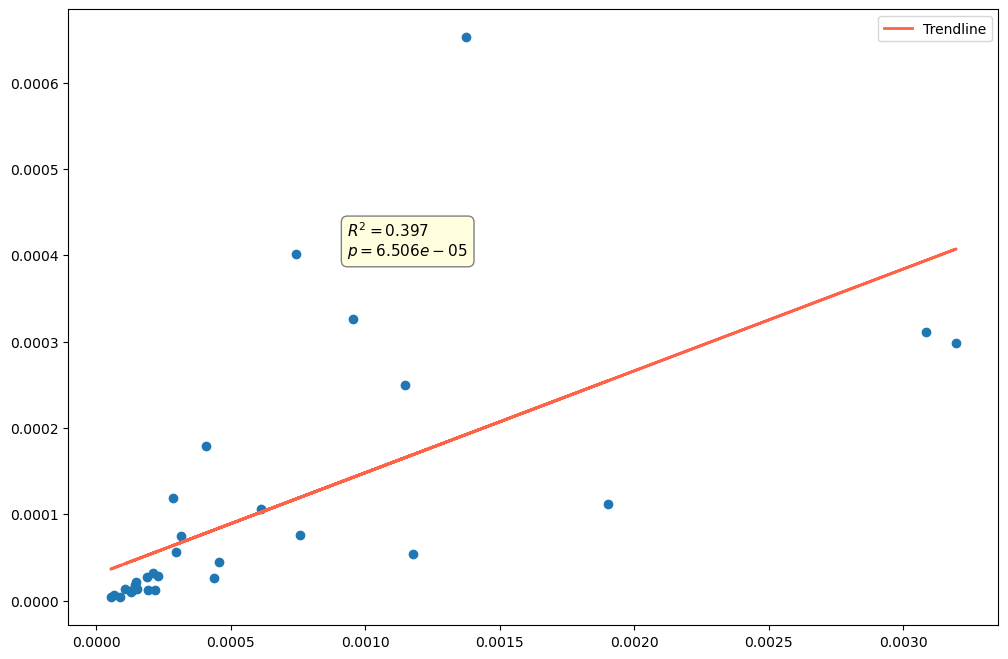

In [49]:
fig, ax3 = plt.subplots(figsize= (12,8))

x= neighbourhood_with_gastronomy_waste_gdf["waste_density"]
y= neighbourhood_with_gastronomy_waste_gdf["gastronomy_density"]

ax3.scatter(x,y)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2
y_line = slope * x + intercept
ax3.plot(x, y_line, color='tomato', linewidth=2, label='Trendline')
x= neighbourhood_with_gastronomy_waste_gdf["waste_density"]
y= neighbourhood_with_gastronomy_waste_gdf["gastronomy_density"]

ax3.annotate(
    f'$R^2 = {r_squared:.3f}$\n$p = {p_value:.3e}$',
    xy=(0.3, 0.6), xycoords='axes fraction', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray')
    
)


plt.legend()
plt.show()